# 10장 설명가능한 AI (Explainable AI)

* "부록3 매트플롯립 입문"에서 한글 폰트를 올바르게 출력하기 위한 설치 방법을 설명했다. 설치 방법은 다음과 같다.

In [ ]:
# 한글 폰트 설치

!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

* 모든 설치가 끝나면 한글 폰트를 바르게 출력하기 위해 **[런타임]** -> **[런타임 다시시작]**을 클릭한 다음, 아래 셀부터 코드를 실행해 주십시오.

In [ ]:
# 라이브러리 임포트

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
# from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# Colab, Linux
# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

# Window
# font_name = "NanumBarunGothic"

# Mac
# font_name = "AppleGothic"

In [ ]:
# 기본 폰트 설정
plt.rcParams['font.family'] = font_name  # window font

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True
plt.rcParams["grid.linestyle"] = ":"

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

## Import modules

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import ipdb


In [19]:
np.random.seed(123)
torch.manual_seed(123)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device = {device}")

device = cuda


## Define model architecture

In [21]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.cn1 = nn.Conv2d(1, 16, 3, 1)
        self.cn2 = nn.Conv2d(16, 32, 3, 1)
        self.dp1 = nn.Dropout2d(0.10)
        self.dp2 = nn.Dropout2d(0.25)
        self.fc1 = nn.Linear(4608, 64) # 4608 is basically 12 X 12 X 32
        self.fc2 = nn.Linear(64, 10)
 
    def forward(self, x):
        x = self.cn1(x)
        x = F.relu(x)
        x = self.cn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dp1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dp2(x)
        x = self.fc2(x)
        op = F.log_softmax(x, dim=1)
        return op

## Define training and inference routines

In [22]:
def train(model, device, train_dataloader, optim, epoch):
    model.train()
    for b_i, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)
        
        pred_prob = model(X)
        loss = F.nll_loss(pred_prob, y) # nll is the negative likelihood loss
        
        optim.zero_grad()
        loss.backward()
        optim.step()
        if b_i % 100 == 0:
            print('epoch: {} [{}/{} ({:.0f}%)]\t training loss: {:.6f}'.format(
                epoch, b_i * len(X), len(train_dataloader.dataset),
                100. * b_i / len(train_dataloader), 
                loss.item()))

In [23]:

def test(model, device, test_dataloader):
    model.eval()
    loss = 0
    success = 0
    with torch.no_grad():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            pred_prob = model(X)
            loss += F.nll_loss(pred_prob, y).item()  # loss summed across the batch
            pred = pred_prob.argmax(dim=1)  # us argmax to get the most likely prediction
            # ipdb.set_trace()
            # success += pred.eq(y.view_as(pred)).sum().item()
            success += (pred == y).float().mean()

    loss /= len(test_dataloader)
    success /= len(test_dataloader)
    print('\nTest dataset: Overall Loss: {:.4f}, Overall Accuracy: {:.3f}%'.format(
        loss, 100. * success))


## Create data loaders

In [24]:
# The mean and standard deviation values are calculated as the mean of all pixel values of all images in the training dataset
path = os.path.join(os.getcwd(), "data")

train_dataloader = torch.utils.data.DataLoader(
    datasets.MNIST(path, train=True, download=True,
                   transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1302,), (0.3069,))])), # train_X.mean()/256. and train_X.std()/256.
                    batch_size=32, shuffle=True)

test_dataloader = torch.utils.data.DataLoader(
    datasets.MNIST(path, train=False, 
                   transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1302,), (0.3069,)) 
                   ])),
                    batch_size=500, shuffle=True)

## Define optimizer and run training epochs

In [25]:
# device = torch.device("cuda")

model = ConvNet().to(device)
optimizer = optim.Adadelta(model.parameters(), lr=0.5)

## model training

In [26]:
for epoch in range(1, 10):
    train(model, device, train_dataloader, optimizer, epoch)
    test(model, device, test_dataloader)

c:\Users\user\anaconda3\envs\torchgpu_py3.12\Lib\site-packages\torch\nn\functional.py:1538: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


epoch: 1 [0/60000 (0%)]	 training loss: 2.309232
epoch: 1 [3200/60000 (5%)]	 training loss: 0.278278
epoch: 1 [6400/60000 (11%)]	 training loss: 0.121370
epoch: 1 [9600/60000 (16%)]	 training loss: 0.181576
epoch: 1 [12800/60000 (21%)]	 training loss: 0.101811
epoch: 1 [16000/60000 (27%)]	 training loss: 0.068833
epoch: 1 [19200/60000 (32%)]	 training loss: 0.138396
epoch: 1 [22400/60000 (37%)]	 training loss: 0.189149
epoch: 1 [25600/60000 (43%)]	 training loss: 0.251213
epoch: 1 [28800/60000 (48%)]	 training loss: 0.009341
epoch: 1 [32000/60000 (53%)]	 training loss: 0.052232
epoch: 1 [35200/60000 (59%)]	 training loss: 0.160566
epoch: 1 [38400/60000 (64%)]	 training loss: 0.013284
epoch: 1 [41600/60000 (69%)]	 training loss: 0.027691
epoch: 1 [44800/60000 (75%)]	 training loss: 0.081332
epoch: 1 [48000/60000 (80%)]	 training loss: 0.237036
epoch: 1 [51200/60000 (85%)]	 training loss: 0.116369
epoch: 1 [54400/60000 (91%)]	 training loss: 0.025693
epoch: 1 [57600/60000 (96%)]	 trainin

## Run inference on trained model

1


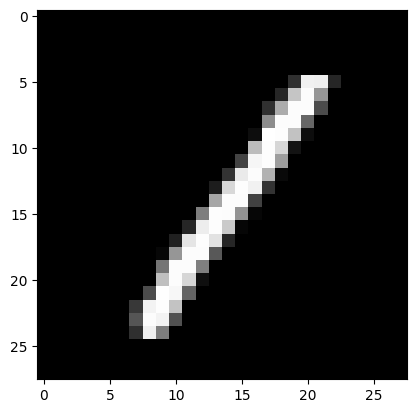

In [31]:
test_samples = enumerate(test_dataloader)
b_i, (sample_data, sample_targets) = next(test_samples)

idx = np.random.randint(0, len(sample_targets))
print(sample_targets[idx].item())
plt.imshow(sample_data[idx][0], cmap='gray', interpolation='none')
plt.show()

In [32]:
idx = np.random.randint(0, len(sample_targets))
sample_data = sample_data.to(device)
print(f"Model prediction is : {model(sample_data).data.max(1)[1][idx]}")
print(f"Ground truth is : {sample_targets[idx]}")

Model prediction is : 1
Ground truth is : 1


### visualize filters

In [33]:
dict(model.named_parameters()).keys()

dict_keys(['cn1.weight', 'cn1.bias', 'cn2.weight', 'cn2.bias', 'fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias'])

In [34]:
model_children_list = list(model.children())
convolutional_layers = []
model_parameters = []
model_children_list
# len(model_children_list)
print("model_children_list[0] = ", model_children_list[0])
print("type(model_children_list[0]) = ", type(model_children_list[0]))
type(model_children_list[0]) == nn.Conv2d # true

print("model_children_list[2] = ", model_children_list[2])
print("type(model_children_list[2]) = ", type(model_children_list[2]))
type(model_children_list[2]) == nn.Dropout2d # true

model_children_list[0] =  Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
type(model_children_list[0]) =  <class 'torch.nn.modules.conv.Conv2d'>
model_children_list[2] =  Dropout2d(p=0.1, inplace=False)
type(model_children_list[2]) =  <class 'torch.nn.modules.dropout.Dropout2d'>


True

In [35]:
for i in range(len(model_children_list)):
    if type(model_children_list[i]) == nn.Conv2d:
        model_parameters.append(model_children_list[i].weight)
        convolutional_layers.append(model_children_list[i])

# len(model_parameters) # 2
# len(model_parameters[0]) # 16
# len(model_parameters[1]) # 32

In [36]:
len(model_parameters) # 2
print(model_parameters[0].shape) # len(model_parameters) # 2
print(model_parameters[1].shape) # torch.Size([32, 16, 3, 3])

torch.Size([16, 1, 3, 3])
torch.Size([32, 16, 3, 3])


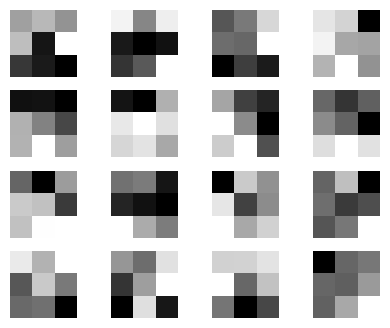

In [37]:
plt.figure(figsize=(5, 4))
for i, flt in enumerate(model_parameters[0]): #
    plt.subplot(4, 4, i+1)
    plt.imshow(flt[0, :, :].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
plt.show()


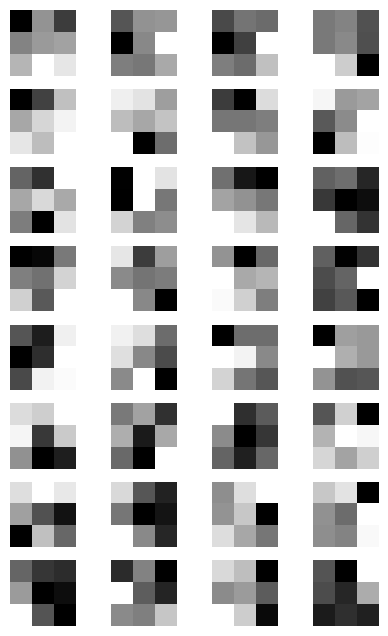

In [38]:
plt.figure(figsize=(5, 8))
for i, flt in enumerate(model_parameters[1]):
    plt.subplot(8, 4, i+1)
    plt.imshow(flt[0, :, :].cpu().detach(), cmap='gray')
    plt.axis('off')
plt.show()

### Visualize feature maps

In [39]:
sample_data.shape

torch.Size([500, 1, 28, 28])

[Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1)),
 Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))]

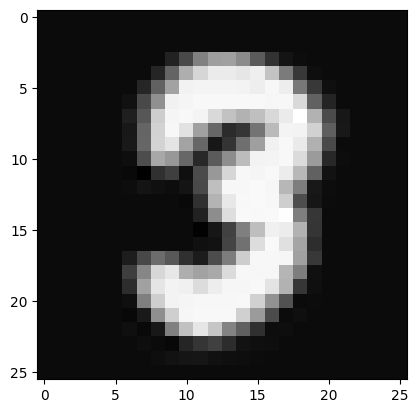

In [40]:
display(convolutional_layers)
per_layer_results = convolutional_layers[0](sample_data)
per_layer_results.shape # torch.Size([500, 16, 26, 26])

plt.imshow(per_layer_results[-1].cpu().data.numpy()[0], cmap = "gray_r")
plt.show()

In [41]:
per_layer_results[-1].shape

torch.Size([16, 26, 26])

In [42]:
per_layer_results = [convolutional_layers[0](sample_data)] # [torch.Size([500, 16, 26, 26])]
for i in range(1, len(convolutional_layers)): 
    per_layer_results.append(convolutional_layers[i](per_layer_results[-1])) # last feature

print(len(per_layer_results))
print("per_layer_results[0] = ")
print(per_layer_results[0].shape)
print(per_layer_results[1].shape)

2
per_layer_results[0] = 
torch.Size([500, 16, 26, 26])
torch.Size([500, 32, 24, 24])


In [43]:
per_layer_results[0].shape[0]

500

torch.Size([16, 26, 26])
<class 'torch.Tensor'>


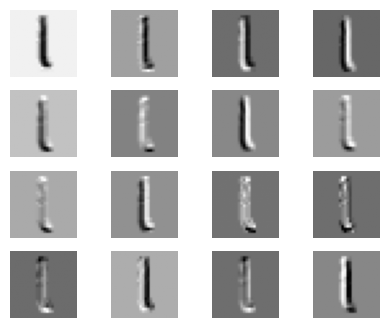

In [44]:
idx = np.random.randint(0, per_layer_results[0].shape[0]) # (0, 500)

plt.figure(figsize=(5, 4))
layer_visualisation = per_layer_results[0][idx, ...] # torch.Size([16, 26, 26])
layer_visualisation = layer_visualisation.data
print(layer_visualisation.size())
print(type(layer_visualisation))
for i, flt in enumerate(layer_visualisation):
    plt.subplot(4, 4, i + 1)
    plt.imshow(flt.cpu().detach(), cmap='gray')
    plt.axis("off")
plt.show()

torch.Size([32, 24, 24])


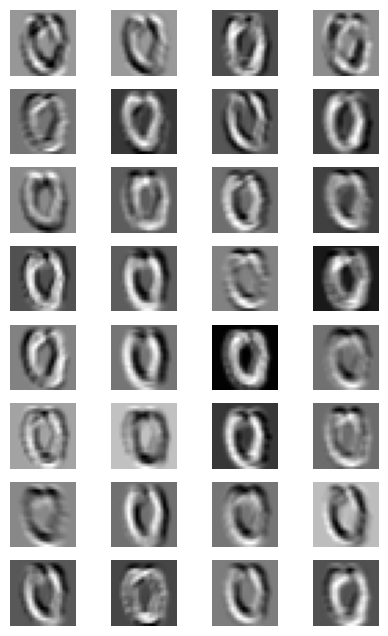

In [46]:
idx = np.random.randint(0, per_layer_results[1].shape[0]) # (0, 500)

plt.figure(figsize=(5, 8))
layer_visualisation = per_layer_results[1][idx, :, :, :]
layer_visualisation = layer_visualisation.data
print(layer_visualisation.size())
for i, flt in enumerate(layer_visualisation):
    plt.subplot(8, 4, i + 1)
    plt.imshow(flt.cpu().detach(), cmap='gray')
    plt.axis("off")
plt.show()

# Captum

## import modules

In [47]:
from captum.attr import IntegratedGradients
from captum.attr import Saliency
from captum.attr import DeepLift
from captum.attr import visualization as viz

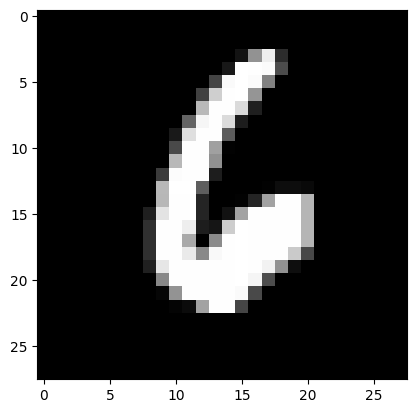

In [48]:
test_samples = enumerate(test_dataloader)
b_i, (sample_data, sample_targets) = next(test_samples)

plt.imshow(sample_data[0][0], cmap='gray', interpolation='none') # bilinear
plt.show()

In [49]:
sample_data = sample_data.to(device)
print(f"Model prediction is : {model(sample_data).data.max(1)[1][0]}")
print(f"Ground truth is : {sample_targets[0]}")

Model prediction is : 6
Ground truth is : 6


## captum tools

In [50]:
print(sample_data.shape)
sample_data[0].unsqueeze(0).shape

torch.Size([500, 1, 28, 28])


torch.Size([1, 1, 28, 28])

In [55]:
captum_input = sample_data[0].unsqueeze(0) # torch.Size([1, 1, 28, 28])
captum_input.requires_grad = True

In [56]:
np.transpose((sample_data[0].cpu().detach().numpy() / 2) + 0.5, (1, 2, 0)).shape

(28, 28, 1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.28787878..1.9106851].


(28, 28, 3)


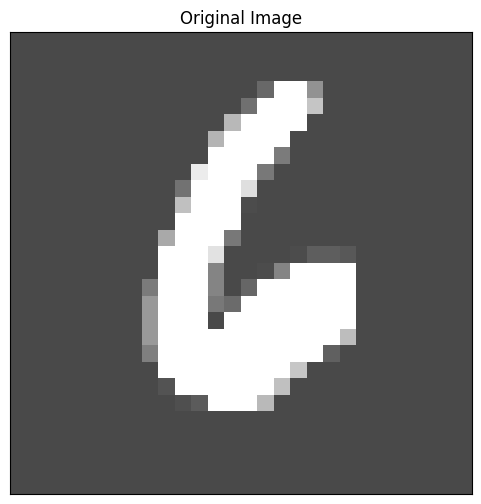

In [62]:
orig_image = np.tile(np.transpose((sample_data[0].cpu().detach().numpy() / 2) + 0.5, (1, 2, 0)), (1,1,3))
print(orig_image.shape)
# tmp = np.transpose((sample_data[0].cpu().detach().numpy() / 2) + 0.5, (1, 2, 0))
# orig_image = np.concatenate([tmp, np.zeros(tmp.shape), np.zeros(tmp.shape)], axis=2)
_ = viz.visualize_image_attr(None, orig_image, cmap='gray', method="original_image", title="Original Image")  # a function that visualizes attribution maps over an image.

In [63]:
sample_targets[0]

tensor(6)

c:\Users\user\anaconda3\envs\torchgpu_py3.12\Lib\site-packages\torch\nn\functional.py:1538: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)
c:\Users\user\anaconda3\envs\torchgpu_py3.12\Lib\site-packages\captum\attr\_utils\visualization.py:51: UserWarning: Attempting to normalize by value approximately 0, visualized resultsmay be misleading. This likely means that attribution values are allclose to 0.
  warnings.warn(


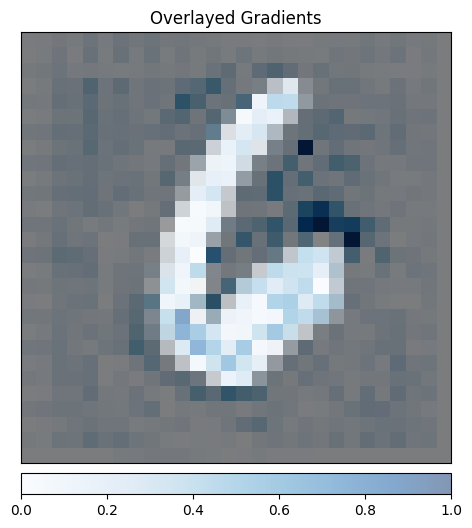

In [ ]:
saliency = Saliency(model) # <class 'captum.attr._core.saliency.Saliency'>, gradient-based saliency map
gradients = saliency.attribute(captum_input, target=sample_targets[0].item()) 
# print(gradients.shape) # torch.Size([1, 1, 28, 28])
gradients = np.reshape(gradients.squeeze().cpu().detach().numpy(), (28, 28, 1))
_ = viz.visualize_image_attr(gradients, orig_image, method="blended_heat_map", 
                             sign="absolute_value",
                             show_colorbar=True, 
                             title="Overlayed Gradients")

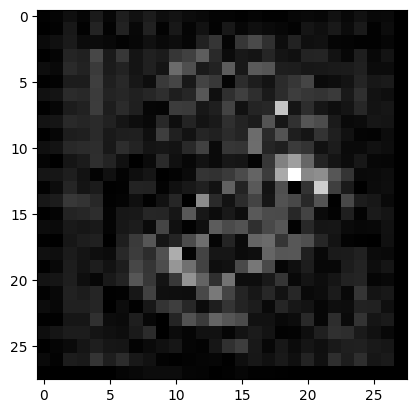

In [67]:
plt.imshow(np.tile(gradients/(np.max(gradients)), (1,1,3)))

c:\Users\user\anaconda3\envs\opencv_torch_py3.12\Lib\site-packages\torch\nn\functional.py:1538: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


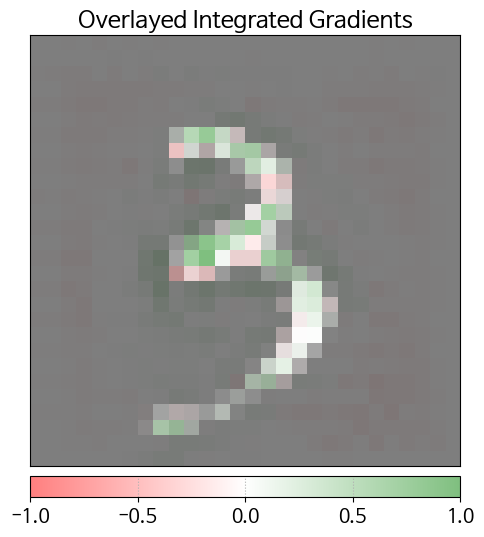

In [ ]:
integ_grads = IntegratedGradients(model) # IG accumulates gradients over multiple interpolated inputs between x and x' making it more reliable than raw gradients.
attributed_ig, delta = integ_grads.attribute(captum_input, 
                                             target=sample_targets[0].item(), 
                                             baselines=captum_input * 0,
                                             return_convergence_delta=True)

attributed_ig = np.reshape(attributed_ig.squeeze().cpu().detach().numpy(), (28, 28, 1))
_ = viz.visualize_image_attr(attributed_ig, orig_image, 
                             method="blended_heat_map",
                             sign="all", 
                             show_colorbar=True, 
                             title="Overlayed Integrated Gradients")

c:\Users\user\anaconda3\envs\torchgpu_py3.12\Lib\site-packages\captum\attr\_core\deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
c:\Users\user\anaconda3\envs\torchgpu_py3.12\Lib\site-packages\torch\nn\functional.py:1538: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)
c:\Users\user\anaconda3\envs\torchgpu_py3.12\Lib\site-packages\captum\attr\_utils\visualization.py:51: UserWarning: Attempting to normalize by value approximately 0, visualized resultsmay be misleadi

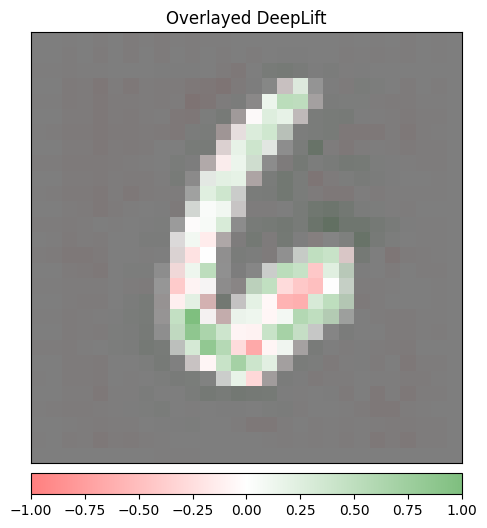

In [68]:
deep_lift = DeepLift(model)
attributed_dl = deep_lift.attribute(captum_input, 
                                    target=sample_targets[0].item(), 
                                    baselines=captum_input * 0,
                                    return_convergence_delta=False)
attributed_dl = np.reshape(attributed_dl.squeeze(0).cpu().detach().numpy(), (28, 28, 1))
_ = viz.visualize_image_attr(attributed_dl, 
                             orig_image, 
                             method="blended_heat_map",
                             sign="all",
                             show_colorbar=True,
                             title="Overlayed DeepLift")